# 성격 유형 분류 머신러닝
- 사람이 외향형인지 내향형인지 분류하는 모델 설계
- 데이터 확인 -> 전처리 -> 모델 학습 -> 평가 -> 성능개선


- 목차
1. 데이터 불러오기
2. 탐색적 데이터분석(EDA)
3. 데이터 전처리
4. 모델 구현
5. 성능 분석
6. 분류 모델 고도화
7. 추가 고도화(pipeline 기반 모델)

|컬럼 이름| 컬럼 정보| 값|
|------|---|---|
|Time_spent_Alone |매일 혼자 보낸 시간 |(0-11시간).|
|Stage_fear| 스테이지 공포의 존재 |(Yes/No).|
|Social_event_attendance| 사회적 사건의 빈도 |(0–10).|
|Going_outside| 외출 빈도| (0–7).|
|Drained_after_socializing| 사교 후 피로감을 느낍니다 |(Yes/No).|
|Friends_circle_size| 친한 친구의 수| (0–15).|
|Post_frequency| 소셜 미디어 포스트 빈도| (0–10).|
|Personality| 목표 변수|(Extrovert/Introvert).|

In [63]:
# 기본 데이터 처리및 시각화 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False


# 전처리 관련 라이브러리
from sklearn.preprocessing import LabelEncoder  # 범주형 변수를 숫자로 변환
from sklearn.impute import SimpleImputer    # 결측치 대체 (초소형 모델)

# 분류 모델 라이브러리
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier  #KNN
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier   # XGBoost

# 데이터분할/ 하이퍼파라미터 튜닝
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# 1. 데이터 불러오기

In [64]:
# 데이터 읽어오기
df = pd.read_csv('data/personality_datasert.csv', encoding='utf-8')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [65]:
target = 'Personality'

features =[col for col in df.columns if col != target]
print(f"target = {target}")
print(f"features = {features}")
len(features)

target = Personality
features = ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']


7

In [66]:
original_df = df.copy(deep=True)

print(f"데이터셋의 행수 : {df.shape[0]}, 열 수 : {df.shape[1]}")

데이터셋의 행수 : 2900, 열 수 : 8


# 2. 탐색적 데이터 분석 (EDA)

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   str    
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   str    
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [68]:
nf = []     # 숫자형 컬럼
cf = []     # 범주형 컬럼

for col in features:
    if df[col].dtype in ['float64','int64','float32','int32']:
        nf.append(col)
    else:
        cf.append(col)
        
print(f"숫자형 데이터셋 개수 : {len(nf)}")
print(f"범주형 데이터셋 개수 : {len(cf)}")

숫자형 데이터셋 개수 : 5
범주형 데이터셋 개수 : 2


In [69]:
df[target].head()

0    Extrovert
1    Introvert
2    Introvert
3    Extrovert
4    Extrovert
Name: Personality, dtype: str

In [70]:
# 고유값 갯수 세기
df[target].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

기본정보 확인 후
- 타겟 클래스가 한쪽으로 치우쳐져 있는지 
- 숫자형 변수들 분포가 왜도가 있는지
- 변수간 상관관계가 강하게 있는지
- 범주형 변수와 타겟의 관계

In [71]:
df.isna().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

In [72]:
df['Personality'].value_counts(normalize=True)

Personality
Extrovert    0.514138
Introvert    0.485862
Name: proportion, dtype: float64

In [73]:
# 클래스의 불균형 분석
personality_counts = df[target].value_counts()

# 고유값별 비율 환산하여 *100 = % 단위로 확인
personality_percentage = df['Personality'].value_counts(normalize=True)*100

for class_val, percentage in personality_percentage.items():
    print(f'클래스 : {class_val}, 비율 : {percentage:.4f}')

클래스 : Extrovert, 비율 : 51.4138
클래스 : Introvert, 비율 : 48.5862


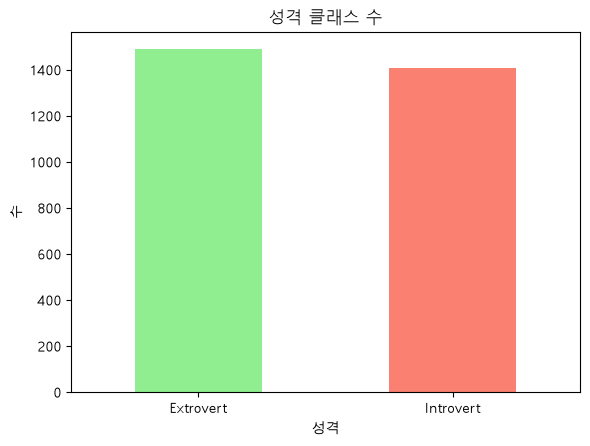

In [74]:
plt.figure(figsize= (6,5))
personality_counts.plot(kind= 'bar', color= ['lightgreen', 'salmon'])
plt.title('성격 클래스 수')
plt.xlabel('성격')
plt.ylabel('수')
plt.tight_layout()
plt.xticks(rotation= 0)
plt.show()

In [75]:
df[nf].describe().T     # 수치형 변수들 통계(+전치)

,count,mean,std,min,25%,50%,75%,max
Time_spent_Alone,2900.0,4.505816,3.441180,0.0,2.0,4.000000,7.0,11.0
Social_event_attendance,2900.0,3.963354,2.872608,0.0,2.0,3.963354,6.0,10.0
Going_outside,2900.0,3.000000,2.221597,0.0,1.0,3.000000,5.0,7.0
Friends_circle_size,2900.0,6.268863,4.232340,0.0,3.0,5.000000,10.0,15.0
Post_frequency,2900.0,3.564727,2.893587,0.0,1.0,3.000000,6.0,10.0


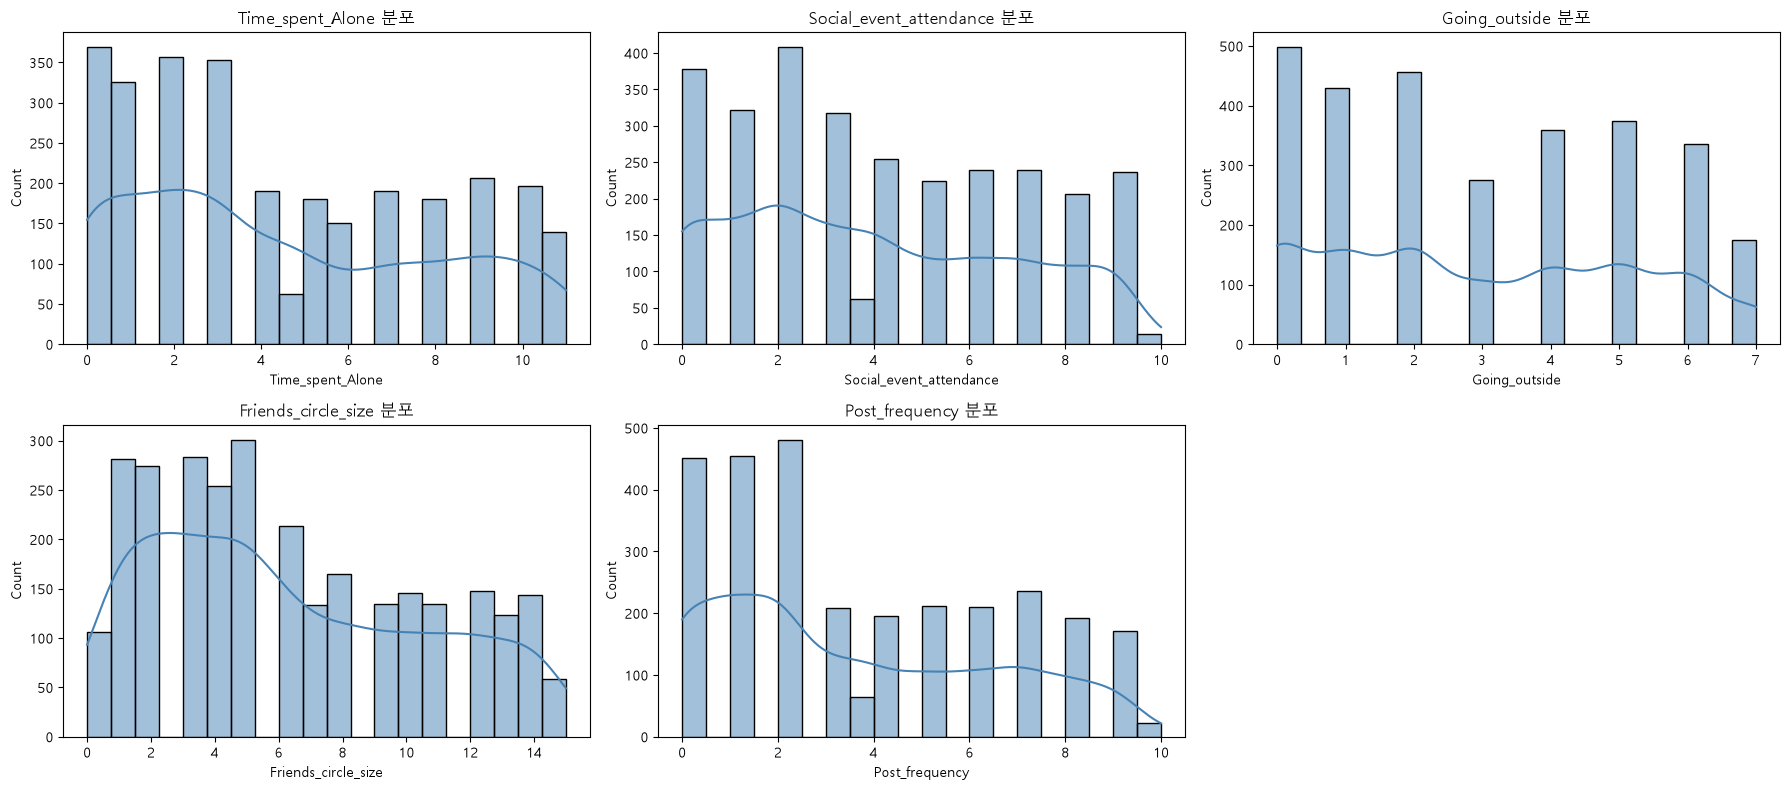

In [76]:
import math

# 숫자형 컬럼들의 분포 히스토그램 시각화
n_cols = 3              # 서브 플롯 열
n_features = len(nf)
# (5 + 3 - 1) // 3  => 2  서브 플롯 행을 데이터 갯수에 따라 유동적으로 서정
n_rows = math.ceil(n_features/n_cols)     # ceil = 올림

figs, axes = plt.subplots(n_rows, n_cols, figsize= (6*n_cols, 4*n_rows))    # (2, 3) / 전체 사이즈는 행과 열에 의해 유동적
axes = axes.flatten()       # 2차원 배열을 1차원으로 변환. axes[i][j] => axes[i]

for i, col in enumerate(nf):
    sns.histplot(
        df[col].dropna(),
        bins = 20,
        kde = True,     # kde 곡선 
        ax = axes[i],
        color = 'steelblue'
    )
    axes[i].set_title(f"{col} 분포")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# 데이터가 없는 빈 subplot 은 숨김 처리
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

완벽하진 않지만 이정도면 양호한 특성 분포를 보인다.

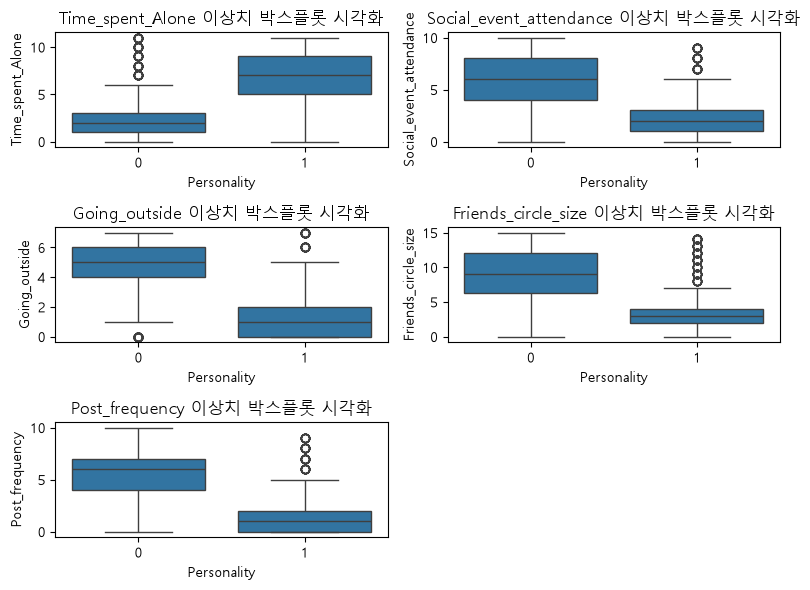

In [93]:
plt.figure(figsize=(8,6))

# 클래스별(타켓) 로 숫자형 변수들의 값 분포 박스플롯 시각화
for i, col in enumerate(nf, 1):     # enumerate(객체 , (시작 인덱스)) : 1로 두면 index 1부터 시작한다는 의미
    plt.subplot(3, 2, i)
    sns.boxplot(x= target, y=col, data= df)     
    plt.title(f'{col} 이상치 박스플롯 시각화')
    
plt.tight_layout()
plt.show()

이상치 처리가 필요하다면 IQR 방식 등을 고려한다.

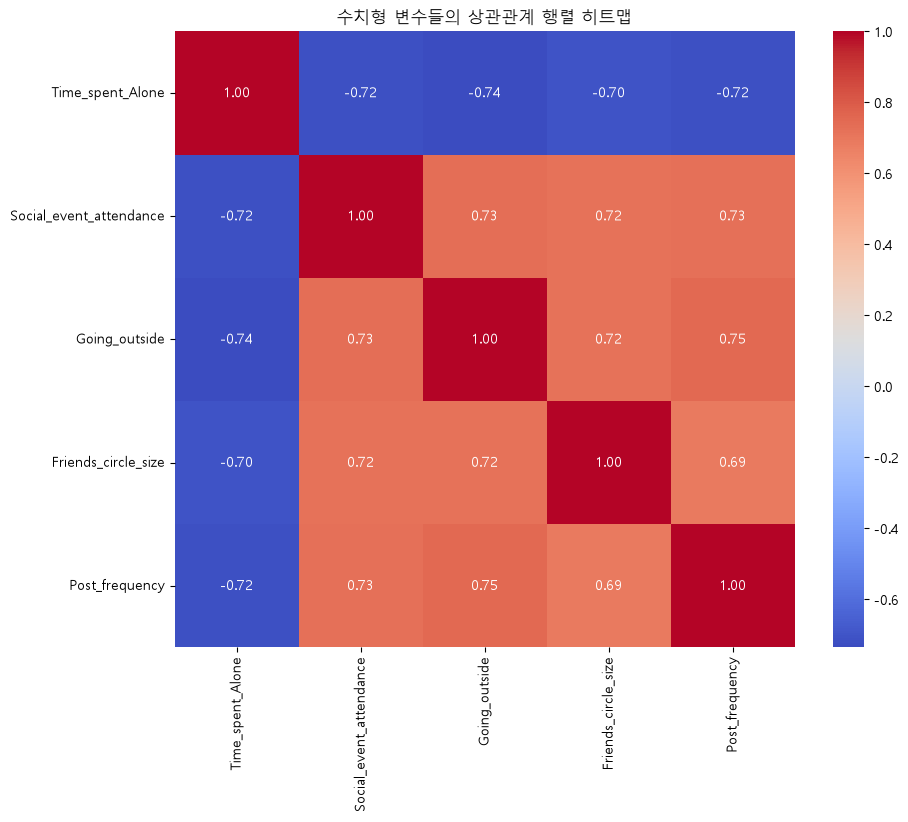

In [78]:
plt.figure(figsize=(10,8))

corr_matrix = df[nf].corr(numeric_only=True)       # 숫자형 변수들의 상관관계  계산

sns.heatmap(
    corr_matrix, 
    annot=True,         # 값 표시
    fmt= '.2f', 
    cmap= 'coolwarm'
    )

plt.title('수치형 변수들의 상관관계 행렬 히트맵')
plt.show()

VIF 지표 확인 : 변수들간의 중복성(다중공선성) 을 확인  
5 가 넘으면 변수 제거를 고려해본다


In [79]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant    # 상수항 추가

vif_df = df[nf].copy()
vif_df = vif_df.dropna()

vif_data = add_constant(vif_df) # 상수항 열 생성

vif_data

,const,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
0,1.0,4.0,4.0,6.0,13.0,5.0
1,1.0,9.0,0.0,0.0,0.0,3.0
2,1.0,9.0,1.0,2.0,5.0,2.0
3,1.0,0.0,6.0,7.0,14.0,8.0
4,1.0,3.0,9.0,4.0,8.0,5.0
...,...,...,...,...,...,...
2895,1.0,3.0,7.0,6.0,6.0,6.0
2896,1.0,3.0,8.0,3.0,14.0,9.0
2897,1.0,4.0,1.0,1.0,4.0,0.0
2898,1.0,11.0,1.0,3.0,2.0,0.0


In [80]:
vif = pd.DataFrame()
vif['features'] = vif_data.columns
vif["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

vif = vif[vif['features'] != 'const']
vif

,features,VIF
1,Time_spent_Alone,2.868138
2,Social_event_attendance,2.977068
3,Going_outside,3.235729
4,Friends_circle_size,2.693871
5,Post_frequency,2.994409


상관계수가 5가 넘으면 삭제를 고려해야 하지만 5가 넘는 컬럼은 없는 것으로 보인다.

### 범주형 자료(cf) 들과 target의 상관관계

In [81]:
cf

['Stage_fear', 'Drained_after_socializing']

In [82]:
ct = pd.crosstab(
    df['Stage_fear'],   # 행 (Stage_fear 로 집계)
    df[target]          # 열 (target 변수로 집계)
)
ct

Personality,Extrovert,Introvert
Stage_fear,,
No,1380,110
Yes,111,1299


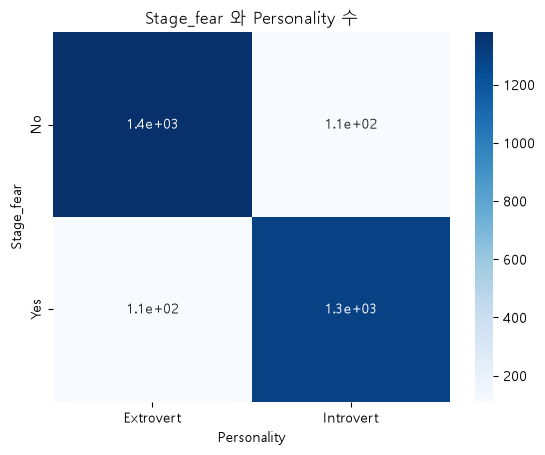

In [83]:
sns.heatmap(ct, annot= True, cmap = 'Blues')
plt.title('Stage_fear 와 Personality 수')
plt.show()

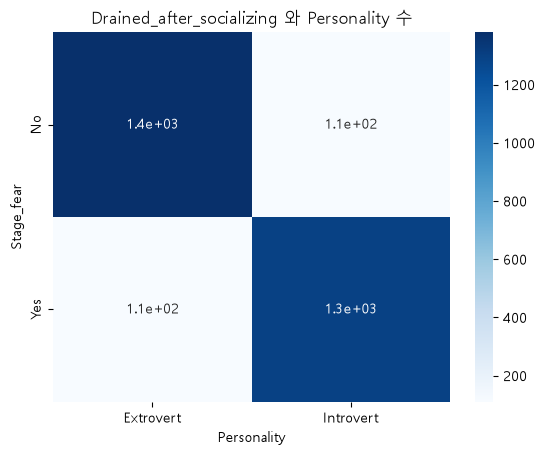

In [84]:
ct = pd.crosstab(df['Stage_fear'], df[target])
sns.heatmap(ct, annot= True, cmap = 'Blues')
plt.title('Drained_after_socializing 와 Personality 수')
plt.show()

범주형 변수 2개가 타겟에 영향을 주는것으로 보아 머신러닝 모델이 특성을 잘 캐치할것으로 판단된다

# 3. 데이터 전처리
- 타겟 인코딩
- 결측치가 있다면 대체 (SimpleImputer, 숫자형은 평균 or 중앙값, 범주형은 최빈값)
- 범주형 변수 인코딩
- 숫자형 변수 이상치는 제거한다면 IQR

In [85]:
df[target].unique()

<StringArray>
['Extrovert', 'Introvert']
Length: 2, dtype: str

In [86]:
# target 값 ['Extrovert', 'Introvert'] 을 [0, 1] 로 변환
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

print(f'변환된 클래스 : {dict(zip(le.classes_, le.transform(le.classes_)))}')

변환된 클래스 : {'Extrovert': np.int64(0), 'Introvert': np.int64(1)}


In [87]:
le.transform(le.classes_)

array([0, 1])

In [88]:
# 수치형 결측값이 있을 시 결측값 처리
numeric_imputer = SimpleImputer(strategy= 'median') # 중앙값으로 결측치를 대체하는 임퓨터 불러오기
df[nf] = numeric_imputer.fit_transform(df[nf])

# 범주형 컬럼에 결측값이 있을시 최빈값으로 처리
categoricla_imputer = SimpleImputer(strategy= 'most_frequent') # 최빈값으로 결츨치를 대체하는 임퓨터 불러오기
df[cf] = categoricla_imputer.fit_transform(df[cf])

In [89]:
#  원-핫 인코딩
df = pd.get_dummies(df, columns= cf, drop_first= True)  #  drop_first= True (기준 카테고리를 하나 제거해서 중복 컬럼 제거)

# 결과가 True , False 일 경우 0/1 정수형으로 변환
bool_cols = df.select_dtypes(include=bool).columns
df[bool_cols] = df[bool_cols].astype(int)
df

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency,Personality,Stage_fear_Yes,Drained_after_socializing_Yes
0,4.0,4.0,6.0,13.0,5.0,0,0,0
1,9.0,0.0,0.0,0.0,3.0,1,1,1
2,9.0,1.0,2.0,5.0,2.0,1,1,1
3,0.0,6.0,7.0,14.0,8.0,0,0,0
4,3.0,9.0,4.0,8.0,5.0,0,0,0
...,...,...,...,...,...,...,...,...
2895,3.0,7.0,6.0,6.0,6.0,0,0,0
2896,3.0,8.0,3.0,14.0,9.0,0,0,0
2897,4.0,1.0,1.0,4.0,0.0,1,1,1
2898,11.0,1.0,3.0,2.0,0.0,1,1,1


In [104]:
encoded_columns = [col for col in df.columns if col != target] # 타겟 제외한 인코딩된 컬럼들

# 수치형 컬럼의 이상치 IQR 방식 활용 제거
for col in nf:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5*IQR)
    upper_bound = Q3 + (1.5*IQR)
    # clip() : 값이 특정 범위를 벗어나지 않도록 하한선, 상한선으로 대체
    df[col] = df[col].clip(lower= lower_bound, upper = upper_bound) # 범위 밖 값 




np.float64(13.5)

# 4. 모델 구현

In [106]:
X = df.drop(columns= [target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,     # 80% : 20%
    stratify= y,        # train/ test 클래스 비율을 비슷하게 유지
    random_state= 42
)

print(len(X_train),len(X_test),len(y_train),len(y_test))

2320 580 2320 580


처음에는 LogisticRegression  
검증 지표 : Accuracy, Precison, Recall, F1-Score

In [1]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,recall_score,
    confusion_matrix, classification_report
    )

# LogisticRegression 모델 정의 및 학습(반복 1000번)
lr = LogisticRegression(random_state= 42, max_iter= 1000)
lr.fit(X_train, y_train)


y_pred_train = lr.predict(X_train)
y_pred = lr.predict(X_test)

print(f"학습 데이터셋 정확도 : {accuracy_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 정밀도 : {precision_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 재현도 : {recall_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 F1-score : {f1_score(y_pred_train, y_train)}")
print('--------------------')
print(f"테스트 셋 정확도 : {accuracy_score(y_pred, y_test)}")
print(f"테스트 셋 정밀도 : {precision_score(y_pred, y_test)}")
print(f"테스트 셋 재현도 : {recall_score(y_pred, y_test)}")
print(f"테스트 셋 F1-score : {f1_score(y_pred_train, y_test)}")
print('--------------------')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
labels = le.classes_

plt.figure(figsize= (6,5))
sns.heatmap(cm, annot=True, fmt= 'd', cmap= 'Blues', xticklabels= labels, yticklabels=labels)
plt.xlabel('정답 예측')
plt.ylabel('실제 정답')
plt.title('LogisticRegression 혼동행렬')
plt.show()


KeyboardInterrupt



로지스틱 사용결과 92% 정도의 정확도로 양호한 성적

RandomForestClassifier : DecisionTree 가 여러개 결합된 형태의 앙상블 모델

학습 데이터셋 정확도 : 0.9849137931034483
학습 데이터셋 정밀도 : 0.9955634427684117
학습 데이터셋 재현도 : 0.9739583333333334
학습 데이터셋 F1-score : 0.9846423870118473
--------------------
테스트 셋 정확도 : 0.9017241379310345
테스트 셋 정밀도 : 0.9078014184397163
테스트 셋 재현도 : 0.89198606271777
테스트 셋 F1-score : 0.9846423870118473
--------------------


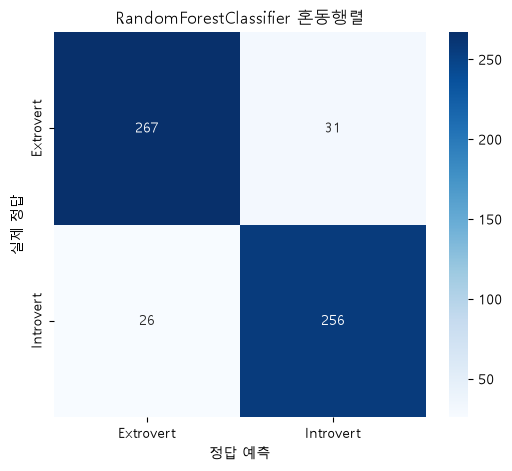

In [119]:

# RandomForestClassifier 모델 정의 및 학습(반복 1000번)
rfc = RandomForestClassifier(random_state= 42)
rfc.fit(X_train, y_train)


y_pred_train = rfc.predict(X_train)
y_pred = rfc.predict(X_test)

print(f"학습 데이터셋 정확도 : {accuracy_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 정밀도 : {precision_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 재현도 : {recall_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 F1-score : {f1_score(y_pred_train, y_train)}")
print('--------------------')
print(f"테스트 셋 정확도 : {accuracy_score(y_pred, y_test)}")
print(f"테스트 셋 정밀도 : {precision_score(y_pred, y_test)}")
print(f"테스트 셋 재현도 : {recall_score(y_pred, y_test)}")
print(f"테스트 셋 F1-score : {f1_score(y_pred_train, y_train)}")
print('--------------------')

cm = confusion_matrix(y_test, y_pred)
labels = le.classes_

plt.figure(figsize= (6,5))
sns.heatmap(cm, annot=True, fmt= 'd', cmap= 'Blues', xticklabels= labels, yticklabels=labels)
plt.xlabel('정답 예측')
plt.ylabel('실제 정답')
plt.title('RandomForestClassifier 혼동행렬')
plt.show()

RandomForestClassifier 모델 사용결과 학습지표가 검증지표보다 월등히 높게 나오는걸로 봐서 과적합이 의심된다.  
하이퍼파라미터 튜닝이 필요해 보임

LogisticRegression 특성 중요도 분석

In [120]:
lr.coef_[0]

array([-0.01401793, -0.02196981, -0.07698559,  0.04878873, -0.09639131,
        2.42491065,  2.49519062])

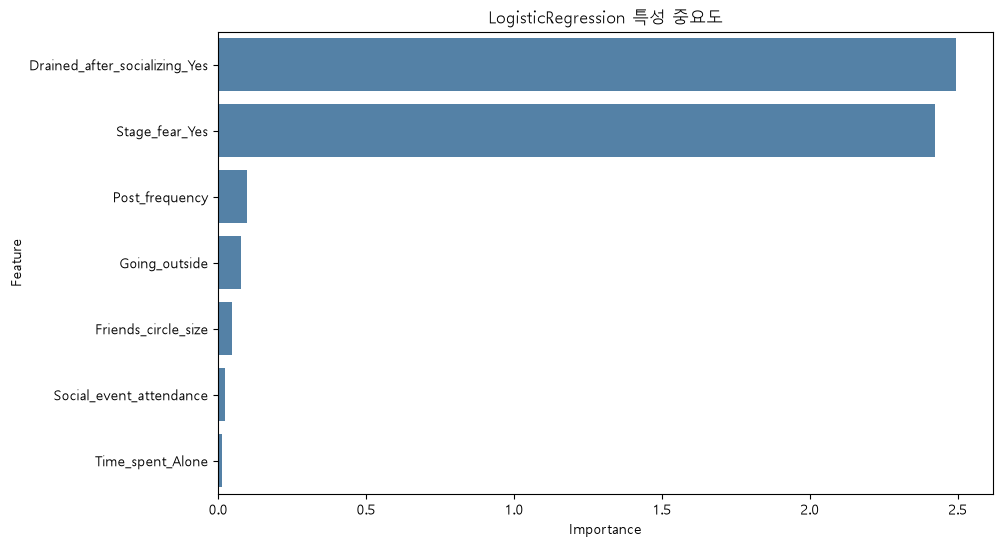

In [121]:
# 이진분류 / 다중분류 일 경우 특성 중요도 뽑기
if len(lr.coef_) == 1:      # 이진분류
    importances = np.abs(lr.coef_[0])
else:   # 다중분류
    importances = np.mean(np.abs(lr.coef_), axis= 0)    # 행을기준(각 특성별로) 클래스들의 평균 중요도
    
# 특성명과 중요도를 중요도 기준으로 내림차순하여 데이터 프레임으로 생성
features_importance = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : importances
}).sort_values(by='Importance', ascending=False)

# 특성중요도 막대그래프 시각화
plt.figure(figsize=(10,6))
sns.barplot(x= "Importance", y= "Feature", data= features_importance, color= 'steelblue')
plt.title('LogisticRegression 특성 중요도')
plt.show()

LogisticRegression은 범주형 변수들을 중요하게 판단함

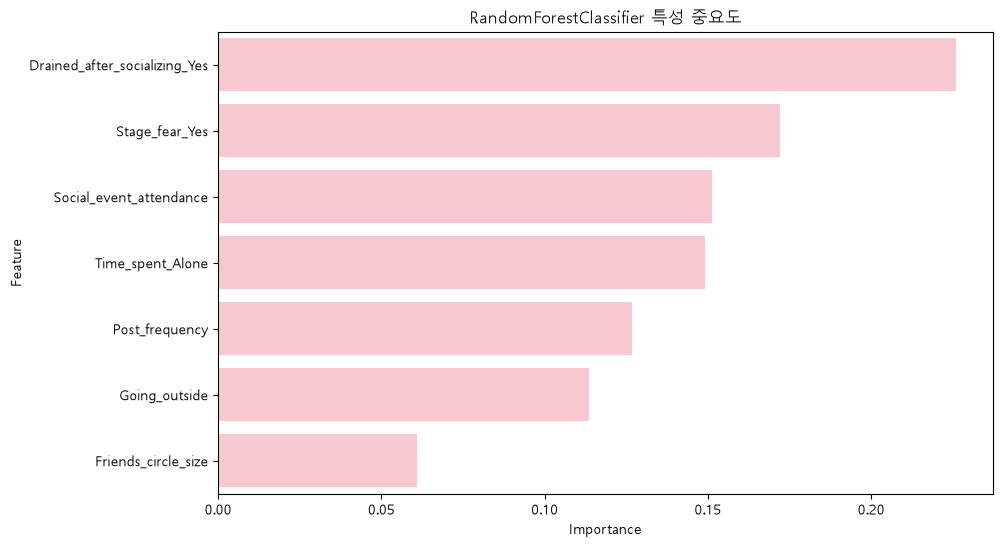

In [124]:
# RandomForestClassifier
# 특성명과 중요도를 중요도 기준으로 내림차순하여 데이터 프레임으로 생성
features_importance = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : rfc.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 특성중요도 막대그래프 시각화
plt.figure(figsize=(10,6))
sns.barplot(x= "Importance", y= "Feature", data= features_importance, color= 'pink')
plt.title('RandomForestClassifier 특성 중요도')
plt.show()

RandomForestClassifier 도 범주형 변수를 가장 중요하게 판단하였으나, 수치형 변수들도 적절한 중요도로 판단함

# 6. 분류 모델 고도화
- RandomizedSearchCV 활용하여 하이퍼파라미터 값 수정
    - LogisticRegression
        - C : 규제 강도
        - solver : 최적화 알고리즘

    - RandomForestClassifier
        - n_estimators : 트리 개수
        - max_depth : 각 트리의 최대깊이
        - min_samples_split : 노드를 나누기 위한 최소 샘플 수

In [ ]:
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 비교할 모델과 하이퍼파라미터 후보를 딕셔너리 형태로 관리
models = {
    'logistic' : {
        'model' : Pipeline([
            ('scaler', StandardScaler()),       # 표준화 (LogisticRegression만 적용)
            ('model' , LogisticRegression(max_iter=1000, random_state=42))  
        ]),
        'params' :{
            'model__C' : np.logspace(-4,4,20),      # 규제강도 후보(10^-4 ~ 10^4 데이터 20개)
            'model__solver' : ['lbfgs', 'liblinear']    # 최적화 알고리즘 후보들
        }
    },
    
    'rf' : {
        'model' : RandomForestClassifier(random_state=42),
        'params' : {
            'n_estimators' : [100, 150],    # 트리 개수
            'max_depth' : [None, 10],       # 트리 최대 깊이
            'min_samples_split' : [2, 5]    # 노드 분할 최소 샘플 수 
        }
    }
}

results = []            # 모델별 성능 결과
optimized_model = {}    # 최적화된 모델

# 모델별 하이퍼 파라미터 탐색
for model_name, mp in models.items():
    # 전체 조합 수보다 n_iter 가 크면 오류발생할 수 있으므로 20보다 작을 때만 파라미터 탐색수 사용하고 아니면 20
    n_iter = min(20, len(list(ParameterGrid(mp['params']))))    
    
    clf = RandomizedSearchCV(
        estimator=mp['model'],          # 탐색할 모델
        param_distributions= mp['params'],  # 탐색할 하이퍼파라미터 후보
        n_iter= n_iter,                 # 랜덤하게 시도할 조합 수
        cv = 3,                         # 3 - fold 교차검증             
        scoring= 'f1_weighted',         # 평가 기준 : 가중 평균 f1-score
        n_jobs= 1,                      # 사용할 CPU 코어 수 (-1 이 들어오면 자동으로 병렬배치)
        random_state=42
    )
    
    clf.fit(X_train, y_train)   

    y_test_pred = clf.best_estimator_.predict(X_test)               # 최적 모델로 테스트 데이터 예측
    test_f1 = f1_score(y_test, y_test_pred, average= 'weighted')    # 테스트 F1 스코어(가중평균)

    optimized_model[model_name] = clf.best_estimator_       # 최적 모델 저장

    results.append({
        'model': model_name,
        'best_cv_score' : clf.best_score_,
        'test_f1' : test_f1,
        'best_params' : clf.best_params_
    })

df_results = pd.DataFrame(results).sort_values(by= 'test_f1', ascending=False)


In [137]:
df_results

,model,best_cv_score,test_f1,best_params
0,logistic,0.938802,0.917248,"{'model__solver': 'lbfgs', 'model__C': 0.00069..."
1,rf,0.938802,0.917248,"{'n_estimators': 100, 'min_samples_split': 2, ..."


# 7. Pipeline 기반 모델 비교
- Pipeline, columnTransformer
    - 전처리, 모델 학습 과정을 하나로 묶어 사용
    - 여러 모델을 같은 전처리 흐름으로 공정하게 비교

In [140]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

advanced_X = original_df.drop(columns=[target])
advanced_y = original_df[target]

target_encoder = LabelEncoder()
advanced_y_encoded = target_encoder.fit_transform(advanced_y)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    advanced_X,
    advanced_y_encoded,
    test_size= 0.2,
    stratify= advanced_y_encoded,
    random_state= 42
)

# 데이터 타입 기준으로 컬럼 선택 후 숫자형/ 범주형 컬럼 분리
numeric_features = advanced_X.select_dtypes(include= np.number).columns.tolist()
categorical_features = advanced_X.select_dtypes(include= "str").columns.tolist()

print(f'numeric_features : {numeric_features}')
print(f'categorical_features : {categorical_features}')

numeric_features : ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
categorical_features : ['Stage_fear', 'Drained_after_socializing']


# 8. 전처리 파이프라인 만들기
- 숫자형 변수 : 결측값을 중앙값으로 채우고, 스케일링 적용
- 범주형 변수 : 결측값을 최빈값으로 채우고, 원-핫 인코딩 적용

In [141]:
# 전처리 파이프라인
def make_prepocessor():
    try:
        onehot = OneHotEncoder(
            drop='first',               # 첫 번째 범주는 제거하여 중복 정보 감소
            handle_unknown='ignore',    # 학습 때 없었던 범주가 나와도 에러발생하지 않음
            sparse_output=False         # 결과를 일반적인 배열 형태로 변환
            )
    except TypeError:
        onehot = OneHotEncoder(drop='first', handle_unknown='ignore', sparse= False)    # 구버전 문법(에러 회피용)
        
    # 숫자형 변수 전처리 파이프라인    
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy= 'median')),     # 결측치는 중앙값으로
        ('scaler', StandardScaler())                        # 평균 0, 표준편차 1 스케일링
    ])
    
    # 범주형 변수 전처리 파이프라인
    categorical_pipe = Pipeline([
        ("imputer" , SimpleImputer(strategy= 'most_frequent')),     # 결측치는 최빈값으로
        ('onehet', onehot)                                          # 원-핫 인코딩
    ])
    
    # 컬럼 종류별로 다른 전처리 적용
    preprocessor = ColumnTransformer([
        ('num', numeric_pipe, numeric_features),        # 숫자형 컬럼에는 numeric_pipe 실행
        ('cat', categorical_pipe, categorical_features) # 범주형 컬럼에는 categorical_pipe 실행
    ])
    
    return preprocessor     # 전처리 완료된 객체 반환

# 9. 여러 모델을 같은 기준으로 비교
- LogisticRegression, RandomForestClassifier, GradientBoostingClassifier (이전 모델의 오차를 보완하며 학습하는 부스팅 계열 모델)

In [142]:
clf.best_params_

{'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 10}

In [145]:
advanced_models = {
    'LogisticRegression' : LogisticRegression(max_iter= 1000, random_state=42),
    'RandomForest' : RandomForestClassifier(n_estimators=100, min_samples_split= 2, max_depth= 10,random_state=0),
    'GradientBoosting' : GradientBoostingClassifier(random_state=42)
}

advanced_results = []       # 모델별 평가 결과
trained_pipelines = {}      # 


for name, estimator in advanced_models.items():
    # 전처리 + 모델을 하나의 파이프 라인으로 묶기
    pipe = Pipeline([
        ("preprocess", make_prepocessor()),
        ('model', estimator)
    ])
    
    pipe.fit(X_train_raw, y_train_raw)
    
    y_pred = pipe.predict(X_test_raw)
    
    advanced_results.append({
        'model' : name,
        'accuracy' : accuracy_score(y_test_raw, y_pred),
        'precision_weighted' : precision_score(y_test_raw, y_pred, average= 'weighted'),    
        'recall_weighted' : recall_score(y_test_raw, y_pred),
        'f1_weighted' : f1_score(y_test_raw, y_pred)
    })
    
    trained_pipelines[name] = pipe

# f1 점수 기준으로 정렬
advanced_results_df = pd.DataFrame(advanced_results).sort_values(by= 'f1_weighted',ascending= False)
advanced_results_df
    
    

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,LogisticRegression,0.917241,0.918324,0.939716,0.916955
2,GradientBoosting,0.917241,0.918324,0.939716,0.916955
1,RandomForest,0.913793,0.914873,0.936170,0.913495


In [146]:
df.columns

Index(['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
       'Friends_circle_size', 'Post_frequency', 'Personality',
       'Stage_fear_Yes', 'Drained_after_socializing_Yes'],
      dtype='str')

In [149]:
best_model_name = advanced_results_df.iloc[1]['model']
best_pipeline = trained_pipelines[best_model_name]

sample_person = pd.DataFrame([{
    'Time_spent_Alone' :3, 
    'Social_event_attendance' : 7,
    'Going_outside' : 6,
    'Friends_circle_size' : 10,
    'Post_frequency' : 7 ,
    'Stage_fear' :'Yes' ,
    'Drained_after_socializing' : "No"
}])

sample_pred = best_pipeline.predict(sample_person)
sample_pred_name = target_encoder.inverse_transform(sample_pred)

print(f'예측된 성격 유형 : {sample_pred_name[0]}')

예측된 성격 유형 : Extrovert


In [ ]:
# 2 단일 조건 필터링

# 나이가 30 이상인 직원 추출
print(df[df['age']>=30])
print('-----------------')

# 특정 도시(예: 서울) 거주 직원찾기
print(df[df['city'] == '서울'])
print(df[df['city'] == '부산'])
print('-----------------')

# 급여가 4000 이상인 직원 필터링
print(df[df['salary'] >= 4000])

  name  age city  salary department  experience
1  이영희   30   부산    4200        마케팅           5
2  박민수   35   대구    3800         개발           8
4  정태현   42   광주    5200         개발          12
5  한소희   31   서울    3900        마케팅           6
-----------------
  name  age city  salary department  experience
0  김철수   25   서울    3500         개발           2
3  최지영   28   서울    4500         기획           3
5  한소희   31   서울    3900        마케팅           6
  name  age city  salary department  experience
1  이영희   30   부산    4200        마케팅           5
6  윤상호   29   부산    3600         기획           4
-----------------
  name  age city  salary department  experience
1  이영희   30   부산    4200        마케팅           5
3  최지영   28   서울    4500         기획           3
4  정태현   42   광주    5200         개발          12
7  배수진   27   대구    4100         개발           3


In [ ]:
# 2 단일 조건 필터링

# 나이가 30 이상인 직원 추출
print(df[df['age']>=30])
print('-----------------')

# 특정 도시(예: 서울) 거주 직원찾기
print(df[df['city'] == '서울'])
print(df[df['city'] == '부산'])
print('-----------------')

# 급여가 4000 이상인 직원 필터링
print(df[df['salary'] >= 4000])

  name  age city  salary department  experience
1  이영희   30   부산    4200        마케팅           5
2  박민수   35   대구    3800         개발           8
4  정태현   42   광주    5200         개발          12
5  한소희   31   서울    3900        마케팅           6
-----------------
  name  age city  salary department  experience
0  김철수   25   서울    3500         개발           2
3  최지영   28   서울    4500         기획           3
5  한소희   31   서울    3900        마케팅           6
  name  age city  salary department  experience
1  이영희   30   부산    4200        마케팅           5
6  윤상호   29   부산    3600         기획           4
-----------------
  name  age city  salary department  experience
1  이영희   30   부산    4200        마케팅           5
3  최지영   28   서울    4500         기획           3
4  정태현   42   광주    5200         개발          12
7  배수진   27   대구    4100         개발           3
